
ANALYSIS 1: PERFORMANCE STATISTICS
                                   mean       std     min       50%     max
method                                                                     
Knapsack                       0.443161  0.034796  0.4000  0.445833  0.5125
Knapsack (Mariginal utiility)  0.691150  0.018469  0.6500  0.700000  0.7000
M0 (Random)                    0.208651  0.112776  0.0500  0.200000  0.5625
M1 (String Matching)           0.398682  0.131077  0.0500  0.404911  0.6250
M3 (Boosted Bandit)            0.576432  0.046664  0.2375  0.575000  0.6250

ANALYSIS 2: RESEARCHER DIVERSITY

M0 (Random) Top 5 Frequent Researchers:
Dennis Lewis       6
Jennifer Foster    6
Eduardo Reed       6
Lisa Perez         5
Jeffrey Butler     5
Name: count, dtype: int64

M1 (String Matching) Top 5 Frequent Researchers:
Jamie Anderson     78
Stacy Miller       71
Scott Campbell     66
Stephen Mullins    66
Lori Dunn          65
Name: count, dtype: int64

M3 (Boosted Bandit) Top 5 Frequent Rese

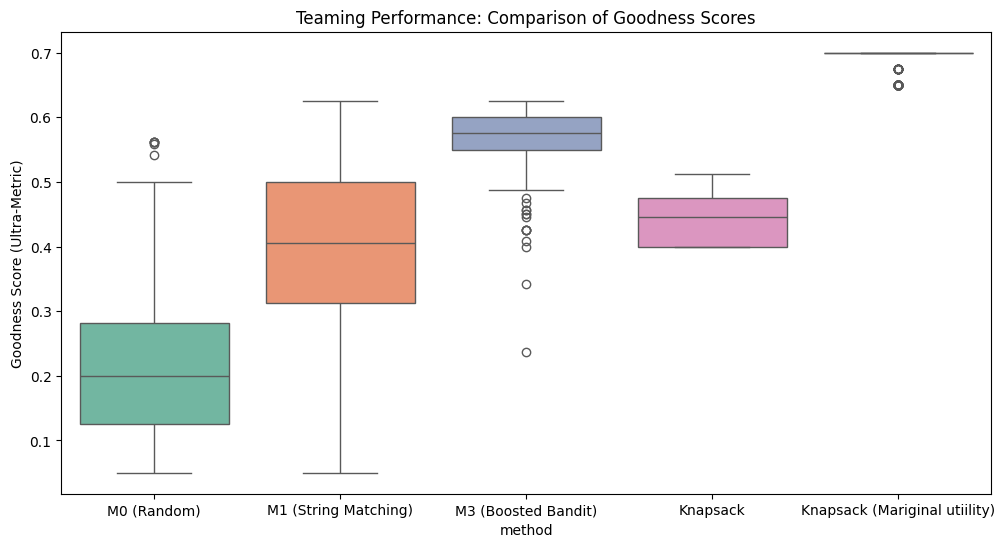

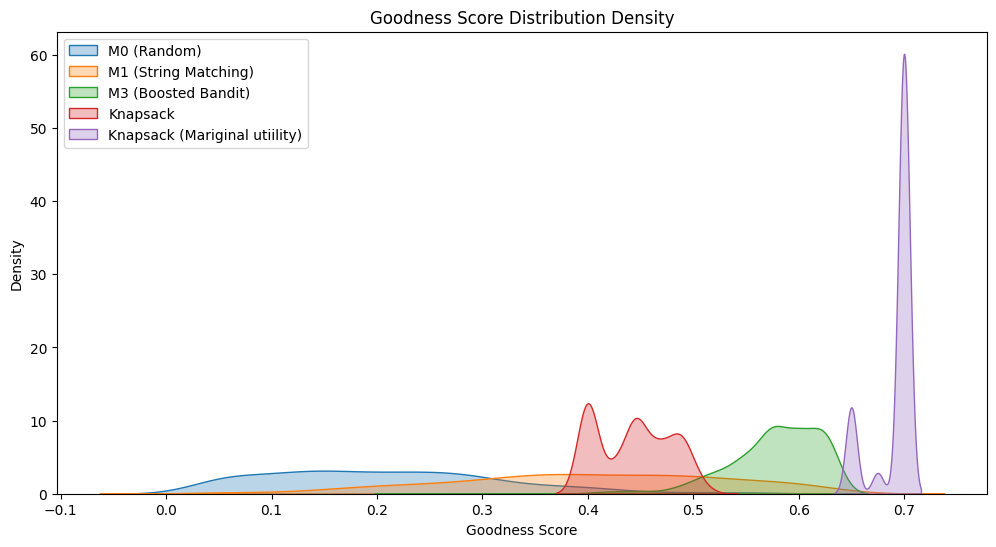

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import warnings

# Suppress specific FutureWarnings from Seaborn
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Setup Configuration
OUTPUT_DIR = "../data/output_data"

# Define the methods and their corresponding file names
file_map = {
    'M0 (Random)': 'teaming_results_m0.csv',
    'M1 (String Matching)': 'teaming_results_m1.csv',
    'M3 (Boosted Bandit)': 'teaming_results_m3.csv',
    'Knapsack': 'knapsackv1.csv',
    'Knapsack (Mariginal utiility)': 'knapsackv2.csv',
}

def load_method_data(method_name, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    if not os.path.exists(path):
        print(f"Skipping {method_name}: File '{filename}' not found.")
        return None
    
    df = pd.read_csv(path)
    
    # Standardize column names
    rename_map = {
        'proposal_link': 'nsf_proposal_links_v0',
        'target_researcher': 'lead_researcher',
        'goodness_ultra': 'goodness_score'
    }
    df = df.rename(columns=rename_map)
    
    # Keep only essential columns
    cols_to_keep = ['nsf_proposal_links_v0', 'lead_researcher', 'team', 'goodness_score']
    df = df[[c for c in cols_to_keep if c in df.columns]]
    df['method'] = method_name
    
    # Convert team string representation back to Python list safely
    if 'team' in df.columns:
        def safe_eval(val):
            if pd.isna(val): return []
            if isinstance(val, str):
                try:
                    return ast.literal_eval(val)
                except:
                    return []
            return val if isinstance(val, list) else []
            
        df['team'] = df['team'].apply(safe_eval)
        df['team_size'] = df['team'].apply(len)
        
    return df

# 2. Load and Combine Data
all_dfs = [load_method_data(name, fname) for name, fname in file_map.items()]
all_dfs = [d for d in all_dfs if d is not None]

if not all_dfs:
    print("Error: No result files found. Please check your file names.")
else:
    comparison_df = pd.concat(all_dfs, ignore_index=True)

    # --- ANALYSIS 1: Performance Statistics ---
    print("\n" + "="*40)
    print("ANALYSIS 1: PERFORMANCE STATISTICS")
    print("="*40)
    stats = comparison_df.groupby('method')['goodness_score'].describe()
    print(stats[['mean', 'std', 'min', '50%', 'max']])
    stats.to_csv('teaming_performance_stats.csv')

    # --- ANALYSIS 2: Visualization (Fixed for palette warning) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=comparison_df, x='method', y='goodness_score', hue='method', palette='Set2', legend=False)
    plt.title('Teaming Performance: Comparison of Goodness Scores')
    plt.ylabel('Goodness Score (Ultra-Metric)')
    plt.savefig('performance_boxplot.png')
    
    plt.figure(figsize=(12, 6))
    for method in comparison_df['method'].unique():
        subset = comparison_df[comparison_df['method'] == method]
        sns.kdeplot(subset['goodness_score'], label=method, fill=True, alpha=0.3)
    plt.title('Goodness Score Distribution Density')
    plt.xlabel('Goodness Score')
    plt.legend()
    plt.savefig('performance_density.png')

    # --- ANALYSIS 3: Diversity & Concentration ---
    print("\n" + "="*40)
    print("ANALYSIS 2: RESEARCHER DIVERSITY")
    print("="*40)
    
    diversity_results = []
    for method in comparison_df['method'].unique():
        m_df = comparison_df[comparison_df['method'] == method]
        
        # Flatten all teams into a single list of names
        all_members = [name for team in m_df['team'] for name in team if name]
        member_counts = pd.Series(all_members).value_counts()
        
        diversity_results.append({
            'Method': method,
            'Unique Researchers': len(member_counts),
            'Top 10 Concentration (%)': (member_counts.head(10).sum() / member_counts.sum() * 100) if not member_counts.empty else 0,
            'Avg Team Size': m_df['team_size'].mean()
        })
        
        print(f"\n{method} Top 5 Frequent Researchers:")
        print(member_counts.head(5))

    diversity_df = pd.DataFrame(diversity_results)
    print("\nDiversity Summary:")
    print(diversity_df)
    diversity_df.to_csv('teaming_diversity_analysis.csv', index=False)

    # --- ANALYSIS 4: Team Similarity (Fixed for TypeError) ---
    print("\n" + "="*40)
    print("ANALYSIS 3: TEAM SIMILARITY (OVERLAP)")
    print("="*40)
    
    def calculate_jaccard(list1, list2):
        # Ensure both inputs are iterable lists/sets and not NaN
        if not isinstance(list1, (list, set, tuple)) or not isinstance(list2, (list, set, tuple)):
            return 0.0
        s1, s2 = set(list1), set(list2)
        if not s1 or not s2: return 0.0
        return len(s1 & s2) / len(s1 | s2) if (s1 | s2) else 0.0

    # Pivot to compare same proposal across different methods
    pivot_df = comparison_df.pivot(index='nsf_proposal_links_v0', columns='method', values='team')
    
    # Compare M1 vs Knapsack if both exist
    if 'M1 (String Matching)' in pivot_df.columns and 'Knapsack (Dynamic)' in pivot_df.columns:
        overlap = pivot_df.apply(lambda x: calculate_jaccard(x['M1 (String Matching)'], x['Knapsack (Dynamic)']), axis=1)
        print(f"Average Team Overlap (M1 vs Knapsack): {overlap.mean():.2%}")

    # Compare M0 vs Knapsack if both exist
    if 'M0 (Random)' in pivot_df.columns and 'Knapsack (Dynamic)' in pivot_df.columns:
        overlap_m0 = pivot_df.apply(lambda x: calculate_jaccard(x['M0 (Random)'], x['Knapsack (Dynamic)']), axis=1)
        print(f"Average Team Overlap (M0 vs Knapsack): {overlap_m0.mean():.2%}")
    
    print("\nAnalysis Complete. Files generated in the current directory.")